 # Анализ цен на Toyota Corolla

 ## 1. Overview

 Columns:
 - Age: Age in years
 - KM: Accumulated Kilometers on odometer
 - FuelType: Fuel Type (Petrol, Diesel, CNG)
 - HP: Horse Power
 - MetColor: Metallic Color? (Yes=1, No=0)
 - Automatic: Automatic (Yes=1, No=0)
 - CC: Cylinder Volume in cubic centimeters
 - Doors: Number of doors
 - Weight: Weight in Kilograms
 - Price: Offer Price in EUROs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

# Загрузка данных
dataset = pd.read_csv('./ToyotaCorolla.csv')
dataset.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23,46986,Diesel,90,1,0,2000,3,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,1170


In [2]:
print("Количество записей:\n", dataset.count())
print("\nСтатистика:\n", dataset.describe())
print("\nПропуски:\n", dataset.isnull().sum())

Количество записей:
 Price        1436
Age          1436
KM           1436
FuelType     1436
HP           1436
MetColor     1436
Automatic    1436
CC           1436
Doors        1436
Weight       1436
dtype: int64

Статистика:
               Price          Age             KM           HP     MetColor  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.674791   
std     3626.964585    18.599988   37506.448872    14.981080     0.468616   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     1.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     1.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

         Automatic           CC        Doors      Weight  
count  1436.000000 

Пропусков в данных нет. \
Признаки не масштабированы, максимальный разброс - 5 порядков. Требуется нормализация.

 ## 2. EDA & Корреляционный анализ

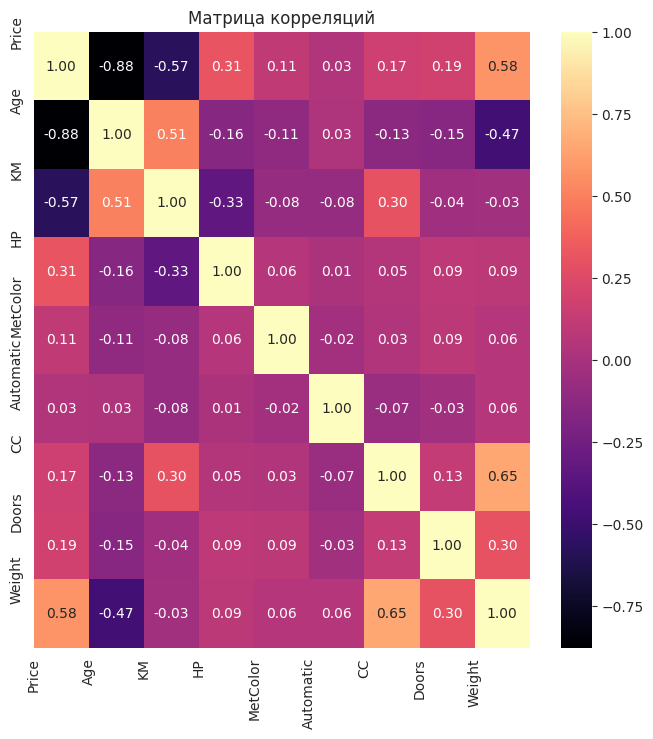

In [3]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

Достаточно сильная отрицательная зависимость наблюдается у признаков Возраст-Цена(-0.88), Пробег-Цена(-0.57), при этом корреляция Возраст-Пробег = 0.51. Более старые машины имеют в среднем больший пробег, следовательно, износ и поэтому стоят меньше. \
Также наблюдается отрицательная зависимость между весом и возрастом(-0.47) машин. \
Сильной корреляцией обладают признаки Вес-Цена(0.58), Вес-Объём(0.65) двигателя, Лошидиные силы-Цена(0.31). Более мощные машины имеют больший по размеру двигатель и стоят дороже.

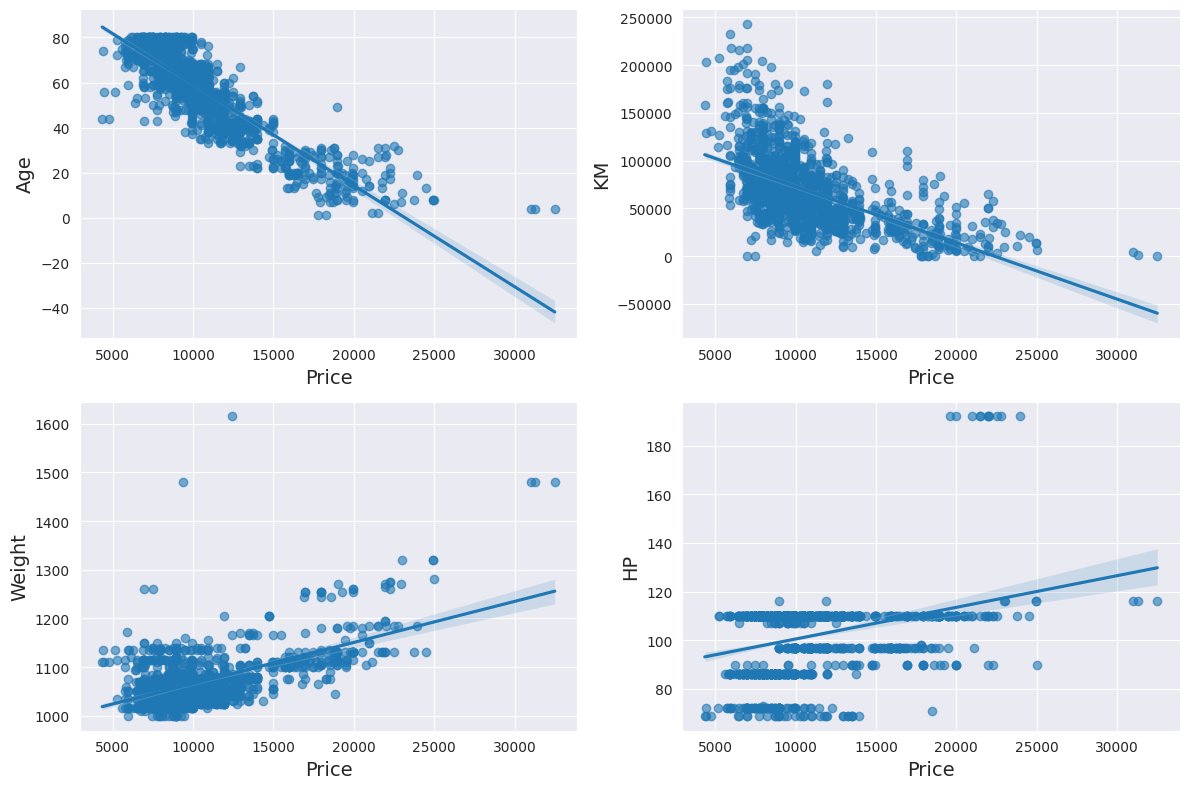

In [4]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='Weight', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('Weight', fontsize=14)

sns.regplot(x='Price', y='HP', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('HP', fontsize=14)

plt.tight_layout()
plt.show()

Отношения Возраста и Цены, Веса и Цены можно приближать линейной функцией.

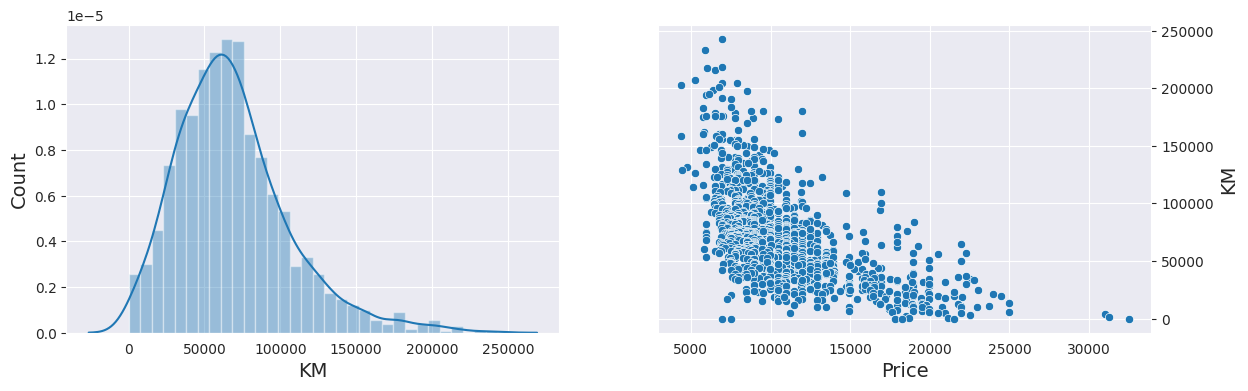

In [5]:
f, axes = plt.subplots(1,2,figsize=(14,4))

sns.distplot(dataset['KM'], ax = axes[0])
axes[0].set_xlabel('KM', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.scatterplot(x = 'Price', y = 'KM', data = dataset, ax = axes[1])
axes[1].set_xlabel('Price', fontsize=14)
axes[1].set_ylabel('KM', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

Данные о количестве машин относительно пробега имеют близкое к нормальному распределений, а соотношение пробега и цены имеет сильный скос.

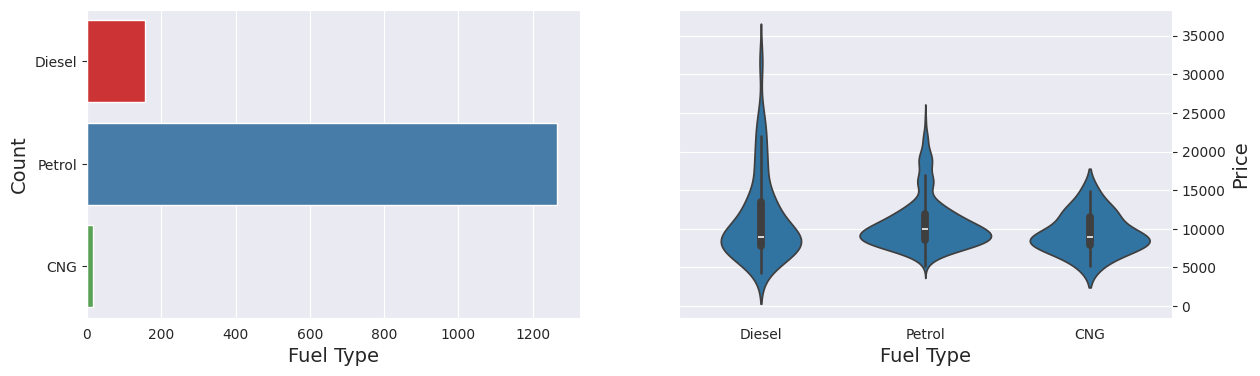

In [6]:
fuel_list= Counter(dataset['FuelType'])
labels = fuel_list.keys()
sizes = fuel_list.values()

f, axes = plt.subplots(1,2,figsize=(14,4))

sns.countplot(dataset['FuelType'], ax = axes[0], palette="Set1")
axes[0].set_xlabel('Fuel Type', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.violinplot(x = 'FuelType', y = 'Price', data = dataset, ax = axes[1])
axes[1].set_xlabel('Fuel Type', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

Большинство машин ездят на бензине. При этом распределение бензиновых автомобилей по цене имеет тяжёлые хвосты(особенно правый). \ 
Тяжёлый хвост имеет также распределение цен на дизельные автомобили.

 ## 3. Подготовка данных

In [7]:
dataset_encoded = pd.get_dummies(dataset, drop_first=True)

X = dataset_encoded.drop('Price', axis=1).values
y = dataset_encoded['Price'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (1077, 10)
Shape of X_test:  (359, 10)


In [8]:
print(set(dataset['FuelType']))
dataset_encoded.head()

{'CNG', 'Diesel', 'Petrol'}


,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,FuelType_Diesel,FuelType_Petrol
0,13500,23,46986,90,1,0,2000,3,1165,True,False
1,13750,23,72937,90,1,0,2000,3,1165,True,False
2,13950,24,41711,90,1,0,2000,3,1165,True,False
3,14950,26,48000,90,0,0,2000,3,1165,True,False
4,13750,30,38500,90,0,0,2000,3,1170,True,False


 ## 4. Базовые регрессионные модели и Анализ остатков

### Метрики регрессии

Пусть:
*   $y_i$ — истинное значение целевой переменной для $i$-го объекта.
*   $\hat{y}_i$ — предсказанное значение модели для $i$-го объекта.
*   $n$ — количество объектов в выборке.

---

#### 1. MSE (Mean Squared Error)
Среднеквадратичная ошибка. Штрафует за большие отклонения, возводя ошибку в квадрат.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

#### 2. RMSE (Root Mean Squared Error)
Корень из среднеквадратичной ошибки. Имеет ту же размерность, что и целевая переменная.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

---

#### 3. MAPE (Mean Absolute Percentage Error)
Средняя абсолютная процентная ошибка. Показывает ошибку в процентах относительно истинных значений.

$$
MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

---

#### 4. R² (Коэффициент детерминации)
Показывает долю дисперсии зависимой переменной, объясняемую рассматриваемой моделью. Максимальное значение — 1. Может быть отрицательным (модель хуже, чем простое среднее).

Обозначим среднее значение истинных значений как $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

In [9]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8827346364187187
R2_score (train):  0.9154713395946548
R2_score (test):  0.74894151542709
RMSE:  1887.5229272467695
MAPE:  0.09488156000126508


 ### Анализ остатков
 По теореме Гаусса-Маркова остатки должны иметь нормальное распределение и не зависеть от прогнозируемых значений (гомоскедастичность).

In [10]:
y_train.ravel().shape
#(1077, 1) -> (1077,)

(1077,)

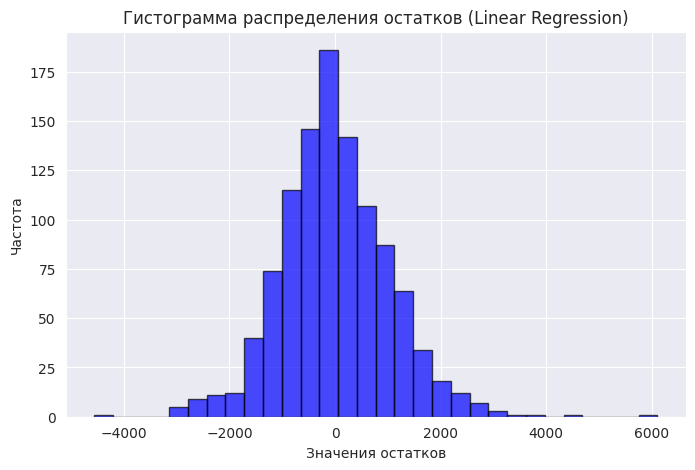

Статистика Колмогорова-Смирнова: 0.0352, P-значение: 1.3606e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


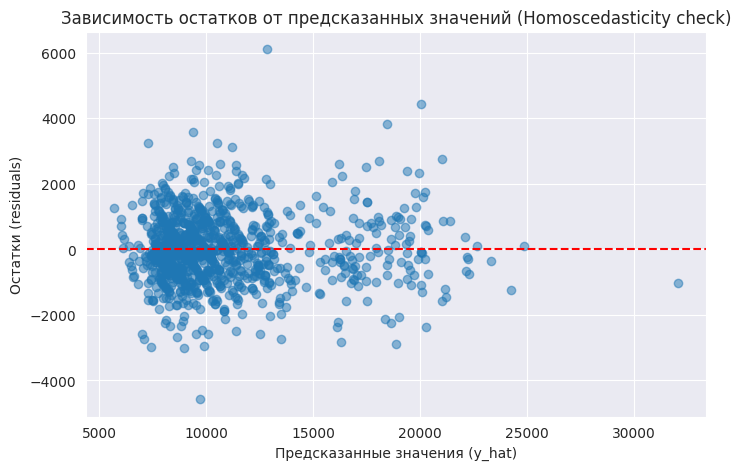

In [11]:
residuals = (y_train.ravel() - y_pred_linear_train.ravel())

def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

 ## 5. Регуляризация с подбором гиперпараметров (GridSearchCV)

In [12]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train.ravel())

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

Лучший параметр alpha для Ridge: 10.0
Ridge Regression Results:
R2 Score (train): 0.9145
R2 Score (test): 0.8117
RMSE: 1634.46
MAPE: 0.0914


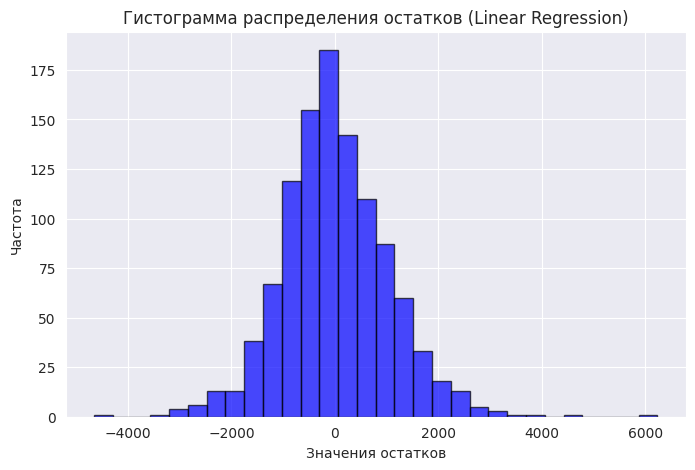

Статистика Колмогорова-Смирнова: 0.0409, P-значение: 5.2675e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


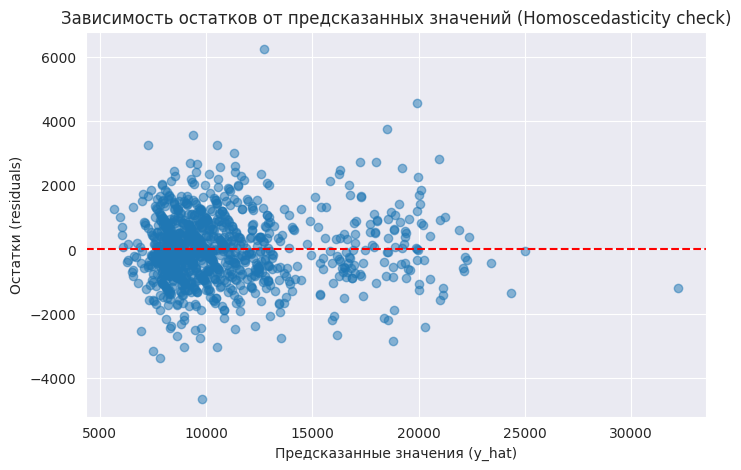

In [13]:
residuals_ridge = (y_train.ravel() - y_pred_ridge_train).ravel()
analyze_residuals(residuals_ridge, y_pred_ridge_train)

In [14]:
lasso_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso(max_iter=5000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train.ravel())

best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

Лучший параметр alpha для Lasso: 10.0
Lasso Regression Results:
R2 Score (train): 0.9119
R2 Score (test): 0.8640
RMSE: 1389.45
MAPE: 0.0890


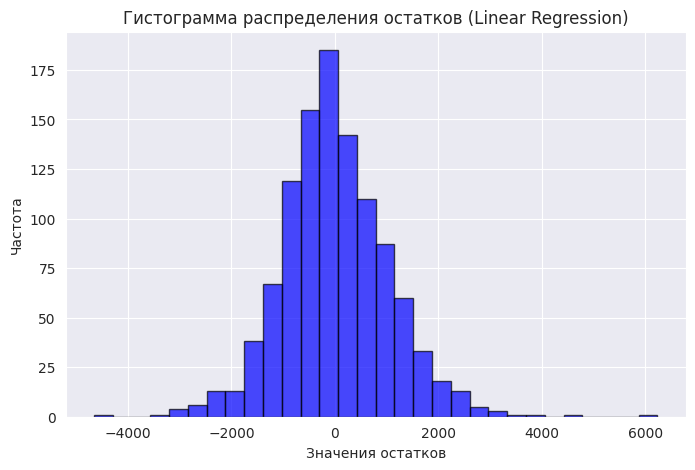

Статистика Колмогорова-Смирнова: 0.0409, P-значение: 5.2675e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


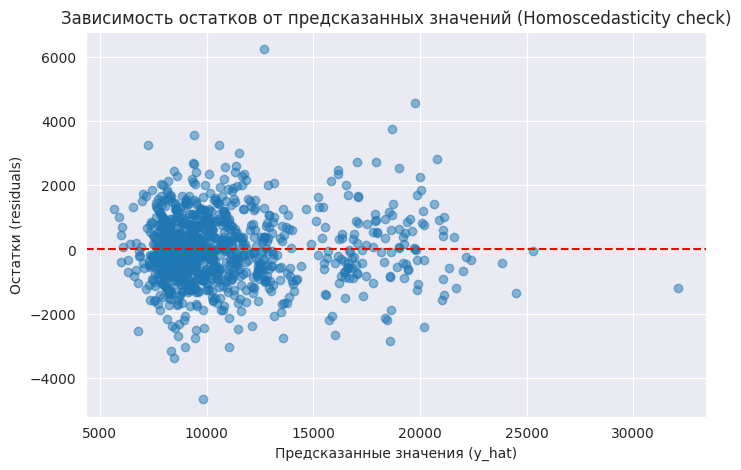

In [15]:
residuals_lasso = (y_train.ravel() - y_pred_lasso_train).ravel()
analyze_residuals(residuals_ridge, y_pred_lasso_train)

 ### Эксперимент: Удаление слабо скоррелированных признаков (corr < 0.05)
 Уберем признаки, которые почти не коррелируют с целевой переменной Price.

In [16]:
corr_matrix = dataset.corr(numeric_only=True)
target_corr = corr_matrix['Price'].abs()
treshold = 0.05
low_corr_cols = target_corr[target_corr <= treshold].index.tolist()

print(f"Признаки с корреляцией < {treshold} по модулю: {low_corr_cols}")

if len(low_corr_cols) > 0:
    X_exp1 = dataset_encoded.drop(columns=['Price'] + low_corr_cols).values
    X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(X_exp1, y, test_size=0.25, random_state=42)

    lr_exp1 = LinearRegression()
    lr_exp1.fit(X_train_e1, y_train_e1)

    y_pred_e1 = lr_exp1.predict(X_test_e1)
    rmse_e1 = np.sqrt(mean_squared_error(y_test_e1, y_pred_e1))
    mape_e1 = mean_absolute_percentage_error(y_test_e1, y_pred_e1)
    r2_test_e1 = r2_score(y_test_e1, y_pred_e1)

    print(f"RMSE после удаления слабых признаков: {rmse_e1:.2f}")
    print(f"MAPE после удаления слабых признаков: {mape_e1:.4f}")
    print(f"R2 (test) после удаления слабых признаков: {r2_test_e1:.4f}")
else:
    print("Нет признаков со столь слабой корреляцией. Эксперимент пропускаем.")

Признаки с корреляцией < 0.05 по модулю: ['Automatic']
RMSE после удаления слабых признаков: 1403.52
MAPE после удаления слабых признаков: 0.0975
R2 (test) после удаления слабых признаков: 0.8612


 ## 6. МНК vs Градиентный спуск
 Продемонстрируем, что модель, обученная ручным градиентным спуском, сходится к тем же результатам (или очень близким), что и аналитическое решение МНК (`LinearRegression`). Для GD обязательна стандартизация данных!

In [17]:
def add_const(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def gradient_descent(X, y, lr=0.01, iterations=5000):
    X_c = add_const(X)
    n, m = X_c.shape
    w = np.zeros(m)
    for k in range(iterations):
        grad = 2 / n * X_c.T @ (X_c @ w - y.ravel())
        w -= lr * grad
    return w


# Для ГС обязательно стандартизируем данные
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# 1. Обучаем ручной Градиентный Спуск
w_gd = gradient_descent(X_train_scaled, y_train_scaled, lr=0.01, iterations=4000)
# Предсказание GD
y_pred_gd_scaled = add_const(X_test_scaled) @ w_gd
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1, 1))

# 2. Обучаем OLS (МНК) из sklearn на тех же масштабированных данных
lr_scaled = LinearRegression(fit_intercept=True)
lr_scaled.fit(X_train_scaled, y_train_scaled.ravel())
w_ols = np.insert(lr_scaled.coef_, 0, lr_scaled.intercept_) # добавляем bias для красоты
y_pred_ols_scaled = lr_scaled.predict(X_test_scaled)
y_pred_ols = scaler_y.inverse_transform(y_pred_ols_scaled.reshape(-1, 1))

# Сравнение весов и результатов
print("Сравнение весов (w0, w1...):")
print(f"Градиентный спуск: \n{w_gd} ...") # Выводим первые 5 для компактности
print(f"Аналитический МНК: \n{w_ols} ...")

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f"\nRMSE Градиентный спуск: {rmse_gd:.4f}")
print(f"RMSE МНК (LinearRegression): {rmse_ols:.4f}")

Сравнение весов (w0, w1...):
Градиентный спуск: 
[ 3.18417903e-16 -6.34259629e-01 -1.55871246e-01  1.81854540e-01
  1.37299516e-02  1.45292570e-02 -1.55138128e-01 -9.53116273e-03
  3.24804937e-01  1.82306466e-01  1.19628812e-01] ...
Аналитический МНК: 
[ 3.03229227e-16 -6.34394424e-01 -1.55247721e-01  1.91752843e-01
  1.38592543e-02  1.52514819e-02 -1.66425854e-01 -8.44493655e-03
  3.21705480e-01  2.04452007e-01  1.25726481e-01] ...

RMSE Градиентный спуск: 1402.5894
RMSE МНК (LinearRegression): 1398.4596


 Видим, что веса и ошибки у МНК и градиентного спуска идентичны (с точностью до погрешности итераций).

 ## 7. Итоговая таблица результатов

In [18]:
models = [
    ('Linear Regression (Base)', rmse_linear, mape_linear, r2_score_linear_test),
    ('Ridge (GridSearchCV)', rmse_ridge, mape_ridge, r2_score_ridge_test),
    ('Lasso (GridSearchCV)', rmse_lasso, mape_lasso, r2_score_lasso_test),
    ('LR (Drop low corr)', rmse_e1 if len(low_corr_cols)>0 else None, mape_e1 if len(low_corr_cols)>0 else None, r2_test_e1 if len(low_corr_cols)>0 else None),
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,Linear Regression (Base),1887.522927,0.094882,0.748942
1,Ridge (GridSearchCV),1634.457320,0.091423,0.811749
2,Lasso (GridSearchCV),1389.451803,0.089018,0.863957
3,LR (Drop low corr),1403.521650,0.097463,0.861187


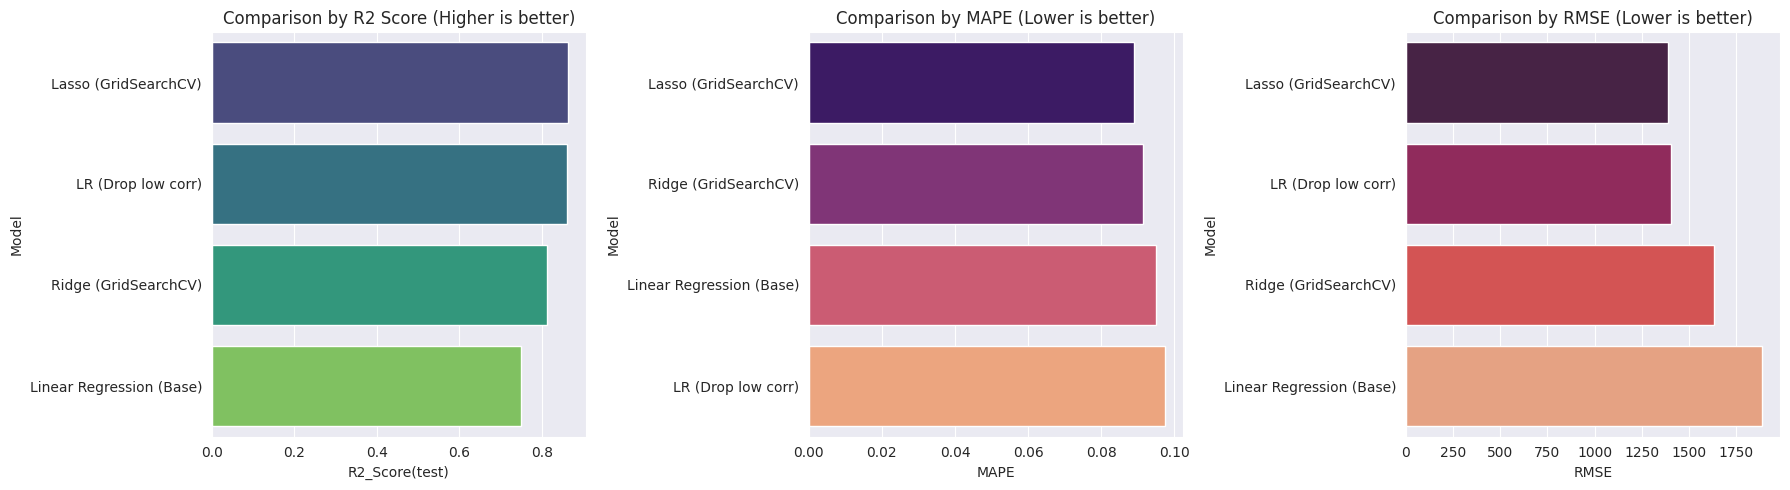

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()